### Problem statement
We want to evaluate whether the Treatment variant leads to a statistically and practically
significant improvement over the Control variant in terms of user conversion 
and then segment users to derive actionable strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings as wn

In [2]:
data = pd.read_csv("ab_test_data.csv")
data.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
print(data.shape)
print(data.info())

(294478, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None


In [4]:
data.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [5]:
data.describe(include=object)

,timestamp,group,landing_page
count,294478,294478,294478
unique,294478,2,2
top,2017-01-16 12:40:24.467417,treatment,old_page
freq,1,147276,147239


In [6]:
data.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted'], dtype='object')

## Phase - 1: Data Cleaning

In [7]:
data.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data['user_id'].duplicated().sum()

np.int64(3894)

In [10]:
data['user_id'].nunique(), len(data)

(290584, 294478)

In [11]:
data[data['user_id'].duplicated(keep=False)].sort_values('user_id')

,user_id,timestamp,group,landing_page,converted
213114,630052,2017-01-07 12:25:54.089486,treatment,old_page,1
230259,630052,2017-01-17 01:16:05.208766,treatment,new_page,0
22513,630126,2017-01-14 13:35:54.778695,treatment,old_page,0
251762,630126,2017-01-19 17:16:00.280440,treatment,new_page,0
11792,630137,2017-01-22 14:59:22.051308,control,new_page,0
...,...,...,...,...,...
99479,945703,2017-01-18 06:39:31.294688,control,old_page,0
40370,945797,2017-01-11 03:04:49.433736,control,new_page,1
186960,945797,2017-01-13 17:23:21.750962,control,old_page,0
131756,945971,2017-01-22 12:43:54.087275,control,new_page,0


In [12]:
pd.crosstab(data['group'], data['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [13]:
data = data[((data['group'] == 'control') & (data['landing_page'] == 'old_page')) |
        ((data['group'] == 'treatment') & (data['landing_page'] == 'new_page'))]

In [14]:
pd.crosstab(data['group'],data['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


In [15]:
data.groupby('user_id')['group'].nunique().value_counts()

group
1    290584
Name: count, dtype: int64

In [16]:
data = data.drop_duplicates(subset='user_id')

In [17]:
data['user_id'].duplicated().sum()

np.int64(0)

In [18]:
data['group'].value_counts(normalize=True)

group
treatment    0.500062
control      0.499938
Name: proportion, dtype: float64

In [19]:
data.shape

(290584, 5)

## Phase 1: Data Cleaning – Insight

After inspecting the dataset, mismatches between group and landing_page were identified and removed to preserve experimental integrity. Duplicate user IDs were also dropped to ensure each user appears only once.

The cleaned dataset contains 290,584 unique users, with an almost perfectly balanced distribution between treatment (50.0062%) and control (49.9938%) groups.

This confirms that the dataset is properly structured for valid A/B test analysis.

## Phase - 2: Hypothesis Testing 

In [20]:
# Group Conversion Rates
group_stats =data.groupby('group')['converted'].agg(['mean','count'])
group_stats

,mean,count
group,,
control,0.120386,145274
treatment,0.118808,145310


In [21]:
## Lift
conv_control = group_stats.loc['control','mean']
conv_treatment = group_stats.loc['treatment','mean']

abs_lift = conv_treatment - conv_control
rel_lift = (abs_lift/conv_control)*100

print(f"Control CR: {conv_control:.4%}")
print(f"Treatment CR: {conv_treatment:.4%}")
print(f"Absolute lift: {abs_lift:.4%}")
print(f"Relative lift: {rel_lift:.2f}%")

Control CR: 12.0386%
Treatment CR: 11.8808%
Absolute lift: -0.1578%
Relative lift: -1.31%


In [22]:
# Number of conversions
convert_counts = np.array([
    data[data['group'] == 'treatment']['converted'].sum(),
    data[data['group'] == 'control']['converted'].sum()
])
convert_counts

array([17264, 17489])

In [23]:
# Number of observations
no_obs = np.array([
    data[data['group'] == 'treatment'].shape[0],
    data[data['group'] == 'control'].shape[0]
])
no_obs

array([145310, 145274])

In [24]:
# Z-test
from statsmodels.stats.proportion import proportions_ztest
z_stat,p_value = proportions_ztest(convert_counts,no_obs,alternative='larger')
print(f"Z-statistic: {z_stat:.4f}, P-value: {p_value:.4f}")

Z-statistic: -1.3109, P-value: 0.9051


In [25]:
# Decision
alpha = 0.05
if p_value < alpha:
    print("Statistically significant: reject null hypothesis")
else:
    print("Not statistically significant: fail to reject null hypothesis")

Not statistically significant: fail to reject null hypothesis


In [26]:
# CONFIDENCE INTERVALS
import statsmodels.api as sm
ci_treatment = sm.stats.proportion_confint(convert_counts[0], no_obs[0], method='normal')
ci_control   = sm.stats.proportion_confint(convert_counts[1], no_obs[1], method='normal')

print(f"95% CI for Control CR: [{ci_control[0]:.4%}, {ci_control[1]:.4%}]")
print(f"95% CI for Treatment CR: [{ci_treatment[0]:.4%}, {ci_treatment[1]:.4%}]")

95% CI for Control CR: [11.8713%, 12.2060%]
95% CI for Treatment CR: [11.7144%, 12.0472%]


In [27]:
# Create contingency table
contingency_table = pd.crosstab(data['group'], data['converted'])
print("Contingency Table:")
print(contingency_table)

Contingency Table:
converted       0      1
group                   
control    127785  17489
treatment  128046  17264


In [28]:
# chi-square test
chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value_chi:.4f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

# Decision based on p-value
alpha = 0.05
if p_value_chi < alpha:
    print("Statistically significant: reject null hypothesis")
else:
    print("Not statistically significant: fail to reject null hypothesis")


Chi-square statistic: 1.7036
P-value: 0.1918
Degrees of freedom: 1
Expected frequencies:
[[127899.65274757  17374.34725243]
 [127931.34725243  17378.65274757]]
Not statistically significant: fail to reject null hypothesis


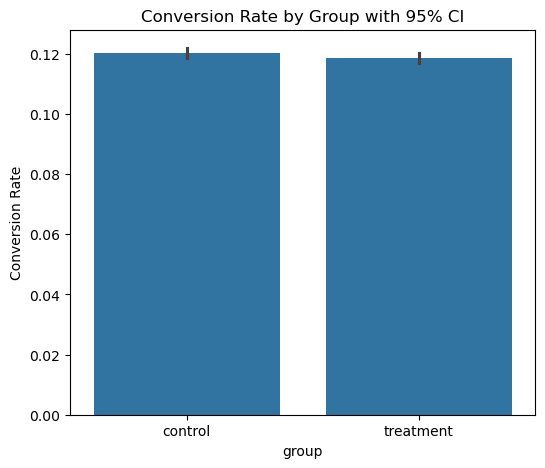

In [29]:
# Visualizing Conversion rates
plt.figure(figsize=(6,5))
sns.barplot(x='group',y='converted',data=data,errorbar=('ci',95))
plt.title("Conversion Rate by Group with 95% CI")
plt.ylabel('Conversion Rate')
plt.show()

### Phase 2: Hypothesis Testing Insights

- Control CR: 12.0386%, Treatment CR: 11.8808%
- Absolute lift: -0.1578%, Relative lift: -1.31%
- Z-test: Z = -1.3109, P-value = 0.9051
- 95% Confidence intervals:
    - Control: [11.8713%, 12.2060%]
    - Treatment: [11.7144%, 12.0472%]
      
A one-sided z-test was conducted to evaluate whether the treatment page performed better than the control page. The test produced a p-value of 0.9051, which is greater than the significance level of 0.05.

Since the p-value exceeds 0.05, we fail to reject the null hypothesis. There is no statistical evidence that the treatment page improves conversion rates over the control page. In fact, the control version shows a slightly higher conversion rate, though the difference is not statistically significant.


## Phase - 3: Customer Segmentation

In [31]:
# Extract Time Features
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['hour'] = data['timestamp'].dt.hour
data['day_of_week'] = data['timestamp'].dt.day_of_week  # 0=Monday
data['is_weekend'] =data['day_of_week'].isin([5,6]).astype(int)

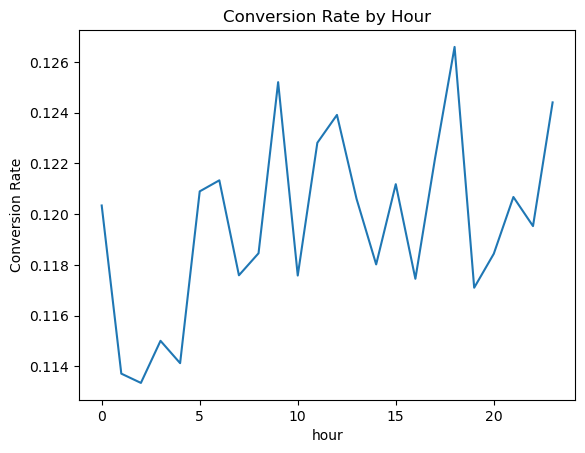

In [32]:
# Conversion by hour
data.groupby('hour')['converted'].mean().plot()
plt.title("Conversion Rate by Hour")
plt.ylabel("Conversion Rate")
plt.show()

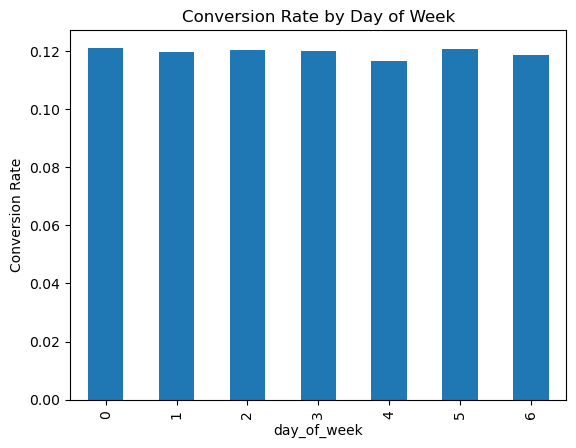

In [34]:
# Conversion by day of week
data.groupby('day_of_week')['converted'].mean().plot(kind='bar')
plt.title("Conversion Rate by Day of Week")
plt.ylabel("Conversion Rate")
plt.show()

In [36]:
# Cluster by time 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ['hour','is_weekend']
scaler = StandardScaler()
scaled =scaler.fit_transform(data[features])

kmeans = KMeans(n_clusters = 3, random_state = 42)
data['cluster'] = kmeans.fit_predict(scaled)

In [37]:
data.groupby('cluster')['converted'].mean()

cluster
0    0.121303
1    0.119647
2    0.117542
Name: converted, dtype: float64

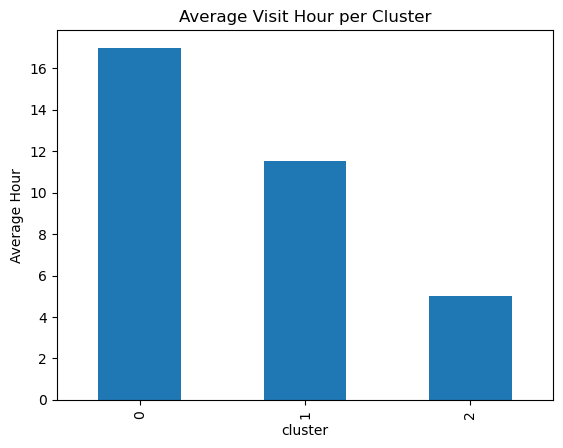

In [42]:
data.groupby('cluster')['hour'].mean().plot(kind='bar')
plt.title("Average Visit Hour per Cluster")
plt.ylabel("Average Hour")
plt.show()

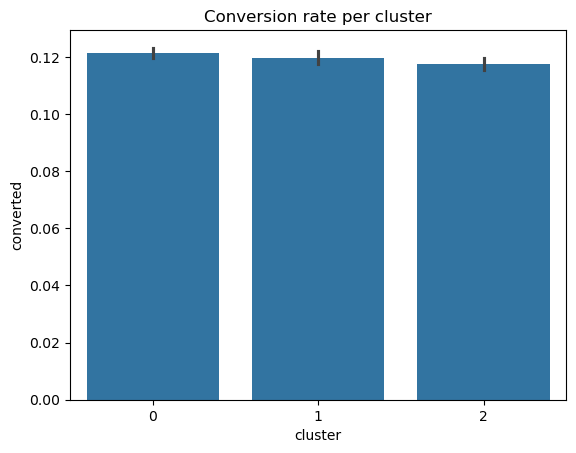

In [40]:
sns.barplot(x='cluster', y='converted', data=data)
plt.title('Conversion rate per cluster')
plt.show()

In [46]:
# Chi - Square Test Across Clusters
contingency = pd.crosstab(data['cluster'], data['converted'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("Chi-square:", chi2)
print("P-value:", p_value)

Chi-square: 7.0401917765831055
P-value: 0.029596597064695435


### Phase - 3: Segmentation Insights

Time-based clustering identified three distinct user groups (early morning, midday, and evening visitors). A chi-square test indicates a statistically significant difference in conversion rates across clusters (p = 0.0296).

However, the absolute differences in conversion rates are small (~0.38 percentage points), suggesting limited practical impact.


### Business Implications

- Conversion rates differ statistically across time-based segments (p < 0.05), indicating that visit timing has some measurable influence on user behavior.

- However, the actual difference in conversion rates between time groups is very small, suggesting limited practical impact.

- Changing ad budgets heavily based on time of day is unlikely to create big improvements.

- Small adjustments or monitoring performance during weaker hours could help slightly.

- Greater impact is likely achievable through landing page optimization and A/B testing rather than time-of-day targeting.

- To find stronger customer segments, we would need more detailed data (like device type, traffic source, or user behavior).

### Assumptions

- Timestamp accurately reflects true user visit time.

- Users are independent observations.

- Conversion tracking is reliable and unbiased.

- Clustering using hour and weekend captures meaningful behavioral timing.

### Statistical Limitations
- Large sample size increases likelihood of detecting small statistically significant differences.

- Practical significance is limited despite statistical significance.

- Limited feature set restricts depth of behavioral segmentation.

- KMeans clustering assumes spherical clusters and equal variance.


# Conclusion
This project evaluated the performance of a new landing page using statistical A/B testing and time-based customer segmentation.

The A/B test results show that the treatment page did not significantly improve conversion rates compared to the control page. The control version achieved a slightly higher conversion rate (12.04%) than the treatment version (11.88%), but the difference was not statistically significant (p > 0.05). Therefore, there is no evidence to support deploying the new landing page in its current form.

Time-based segmentation identified three behavioral user groups based on visit hour. Although statistical testing indicated significant differences in conversion across time clusters, the magnitude of these differences was very small. This suggests limited practical value in optimizing performance purely based on visit timing.

Overall, the findings highlight the importance of distinguishing statistical significance from practical significance when making business decisions. Based on the current evidence, implementing the new landing page would not be recommended without further optimization and additional experimentation.

Future improvements could include incorporating richer behavioral or demographic features to enable deeper and more actionable segmentation.